In [1]:
import numpy as np
import modgen2d as mg2d
import helper_functions as hf

In [2]:
import warnings
from time import perf_counter

import gstools as gs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

from modgen2d.spatial_simulator2d import (
    CovarianceDecompositionSimulator,
    GSToolsSimulator,
)

try:
    from memory_profiler import memory_usage
except ImportError:
    memory_usage = None
    warnings.warn(
        "For peak-memory measurement, install: "
        "`pip install memory-profiler psutil`"
    )


In [3]:
def make_grid(x_span, z_span, nx, nz):
    """Create cell-center coordinates for a regular grid."""

    dx_local = x_span / nx
    dz_local = z_span / nz

    x_local = (np.arange(nx) + 0.5) * dx_local
    z_local = (np.arange(nz) + 0.5) * dz_local

    xx_local, zz_local = np.meshgrid(
        x_local,
        z_local,
        indexing="ij",
    )

    points_local = np.column_stack(
        (
            xx_local.ravel(),
            zz_local.ravel(),
        )
    )

    return x_local, z_local, points_local


def build_simulator(method, seed, mode_no=1000):
    """Construct one spatial simulator."""

    rng = np.random.default_rng(seed)

    if method == "CMD":
        return CovarianceDecompositionSimulator(
            theta_x=theta_x,
            theta_z=theta_z,
            rng=rng,
        )

    if method == "GSTools":
        return GSToolsSimulator(
            theta_x=theta_x,
            theta_z=theta_z,
            mode_no=mode_no,
            rng=rng,
        )

    raise ValueError(f"Unknown method: {method}")


def simulate_one(simulator, points, shape):
    """Generate one standardized realization."""

    values = simulator.simulate(
        points=points,
        mean=0,
        sigma=1,
    )

    return np.asarray(values).reshape(shape)


def generate_ensemble(
    method,
    points,
    shape,
    n_realizations,
    seed,
    mode_no=1000,
):
    """Generate multiple standardized random fields."""

    simulator = build_simulator(
        method=method,
        seed=seed,
        mode_no=mode_no,
    )

    fields = []

    for _ in range(n_realizations):
        field = simulate_one(
            simulator=simulator,
            points=points,
            shape=shape,
        )

        fields.append(field)

    return np.stack(fields)


def directional_variogram_by_realization(
    fields,
    spacing,
    direction,
    max_lag=None,
):
    """
    Calculate directional semivariograms for every realization.

    Parameters
    ----------
    fields : ndarray
        Shape: (n_realizations, nx, nz).
    spacing : float
        Grid spacing along the selected direction.
    direction : {"x", "z"}
        Direction of the variogram.
    max_lag : int, optional
        Maximum lag measured in grid cells.

    Returns
    -------
    lag_distances : ndarray
        Lag distances in physical units.
    gamma : ndarray
        Shape: (n_realizations, n_lags).
    """

    if fields.ndim != 3:
        raise ValueError(
            "fields must have shape (n_realizations, nx, nz)"
        )

    if direction == "x":
        spatial_axis = 1
    elif direction == "z":
        spatial_axis = 2
    else:
        raise ValueError("direction must be 'x' or 'z'")

    available_lags = fields.shape[spatial_axis] - 1

    if max_lag is None:
        max_lag = max(1, available_lags // 2)

    max_lag = min(max_lag, available_lags)

    lag_indices = np.arange(1, max_lag + 1)

    gamma = np.empty(
        (
            fields.shape[0],
            max_lag,
        )
    )

    for j, lag in enumerate(lag_indices):

        if direction == "x":
            difference = (
                fields[:, lag:, :]
                - fields[:, :-lag, :]
            )
        else:
            difference = (
                fields[:, :, lag:]
                - fields[:, :, :-lag]
            )

        gamma[:, j] = 0.5 * np.mean(
            difference**2,
            axis=(1, 2),
        )

    lag_distances = lag_indices * spacing

    return lag_distances, gamma


def summarize_variogram(lags, gamma_by_realization):
    """Calculate ensemble mean and 95% confidence interval."""

    mean_gamma = gamma_by_realization.mean(axis=0)

    standard_error = (
        gamma_by_realization.std(axis=0, ddof=1)
        / np.sqrt(gamma_by_realization.shape[0])
    )

    ci95 = 1.96 * standard_error

    return lags, mean_gamma, ci95


def target_variogram(method, lags, direction):
    """Calculate the prescribed directional variogram."""

    if method in ["CMD", "GSTools"]:

        theta = (
            theta_x
            if direction == "x"
            else theta_z
        )

        # CMD correlation:
        # rho(h) = exp(-2h/theta)
        return 1.0 - np.exp(
            -2.0 * lags / theta
        )

    if method == "GSTools":

        model = gs.Gaussian(
            dim=2,
            var=1.0,
            len_scale=[theta_x, theta_z],
            angles=0.0,
        )

        axis = 0 if direction == "x" else 1

        return model.vario_axis(
            lags,
            axis=axis,
        )

    raise ValueError(f"Unknown method: {method}")


def fit_length_scale(
    method,
    lags,
    empirical_gamma,
    initial_theta,
):
    """Estimate correlation-length parameter from empirical variogram."""

    if method in ["CMD", "GSTools"]:

        def model_function(h, theta):
            return 1.0 - np.exp(
                -2.0 * h / theta
            )

    elif method == "GSTools":

        def model_function(h, theta):

            model = gs.Gaussian(
                dim=1,
                var=1.0,
                len_scale=theta,
            )

            return model.variogram(h)

    else:
        raise ValueError(f"Unknown method: {method}")

    fitted_parameters, _ = curve_fit(
        model_function,
        lags,
        empirical_gamma,
        p0=[initial_theta],
        bounds=(
            np.finfo(float).eps,
            np.inf,
        ),
    )

    return float(fitted_parameters[0])


def simulation_task(
    method,
    points,
    shape,
    seed,
    mode_no=1000,
):
    """Construct a simulator and generate one field."""

    simulator = build_simulator(
        method=method,
        seed=seed,
        mode_no=mode_no,
    )

    return simulate_one(
        simulator=simulator,
        points=points,
        shape=shape,
    )


def measure_time_and_peak_memory(
    function,
    *args,
    **kwargs,
):
    """
    Measure wall-clock time and approximate additional peak memory.

    For publication-quality memory measurements, run each
    configuration in a fresh process.
    """

    start = perf_counter()

    if memory_usage is None:

        result = function(
            *args,
            **kwargs,
        )

        elapsed = perf_counter() - start

        return result, elapsed, np.nan

    baseline_mib = memory_usage(
        -1,
        interval=0.01,
        timeout=0.1,
    )[0]

    peak_mib, result = memory_usage(
        (
            function,
            args,
            kwargs,
        ),
        interval=0.01,
        max_usage=True,
        retval=True,
        include_children=True,
    )

    elapsed = perf_counter() - start

    additional_peak_mib = max(
        0.0,
        peak_mib - baseline_mib,
    )

    return (
        result,
        elapsed,
        additional_peak_mib,
    )


Grid: 30 x 20 = 600 cells


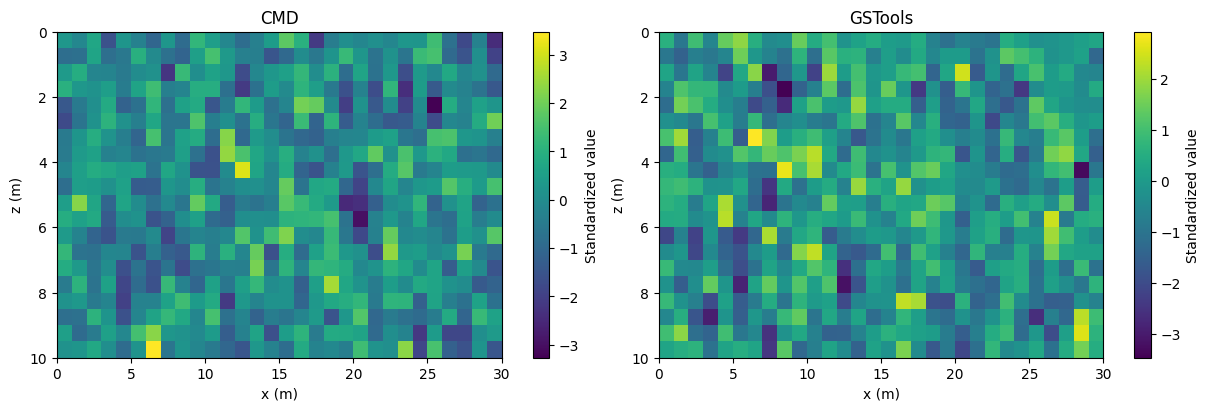

In [4]:
# 1. Verification settings

# Use a relatively small grid because covariance decomposition
# constructs and decomposes a dense N x N covariance matrix.
x_span = 30.0
z_span = 10.0

dx = 1.0
dz = 0.5

# Correlation-length parameters
theta_x = 1.0
theta_z = 1.0

# Ensemble settings
n_realizations = 50
mode_no = 1000
base_seed = 42


# 2. Construct regular verification grid
x = np.arange(dx / 2, x_span, dx)
z = np.arange(dz / 2, z_span, dz)

xx, zz = np.meshgrid(x, z, indexing="ij")

# Required input format: [[x1, z1], [x2, z2], ...]
points = np.column_stack(
    (
        xx.ravel(),
        zz.ravel(),
    )
)

field_shape = (len(x), len(z))

print(
    f"Grid: {field_shape[0]} x {field_shape[1]} "
    f"= {points.shape[0]:,} cells"
)


# Generate and plot one realization from each method
representative_fields = {}

for i, method in enumerate(("CMD", "GSTools")):

    simulator = build_simulator(
        method=method,
        seed=base_seed + i,
        mode_no=mode_no,
    )

    representative_fields[method] = simulate_one(
        simulator=simulator,
        points=points,
        shape=field_shape,
    )


fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4),
    constrained_layout=True,
)

for ax, method in zip(
    axes,
    ("CMD", "GSTools"),
):

    image = ax.pcolormesh(
        x,
        z,
        representative_fields[method].T,
        shading="auto",
        cmap="viridis",
    )

    ax.invert_yaxis()
    ax.set_title(method)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("z (m)")

    fig.colorbar(
        image,
        ax=ax,
        label="Standardized value",
    )

plt.show()



In [5]:
# Generate ensembles

ensembles = {}

for i, method in enumerate(("CMD", "GSTools")):

    start = perf_counter()

    ensembles[method] = generate_ensemble(
        method=method,
        points=points,
        shape=field_shape,
        n_realizations=n_realizations,
        seed=base_seed + i,
        mode_no=mode_no,
    )

    elapsed = perf_counter() - start

    print(
        f"{method}: generated {n_realizations} "
        f"realizations in {elapsed:.2f} s"
    )


# Verify marginal mean and variance
marginal_summary = []

for method, fields in ensembles.items():

    marginal_summary.append(
        {
            "method": method,
            "ensemble_mean": fields.mean(),
            "ensemble_variance": fields.var(ddof=1),
            "n_realizations": fields.shape[0],
            "n_cells_per_realization": (
                fields.shape[1] * fields.shape[2]
            ),
        }
    )

marginal_summary = pd.DataFrame(
    marginal_summary
)

print("\nMarginal-statistics verification:")
print(marginal_summary)

CMD: generated 50 realizations in 3.45 s
GSTools: generated 50 realizations in 2.86 s

Marginal-statistics verification:
    method  ensemble_mean  ensemble_variance  n_realizations  \
0      CMD       0.013537           1.014878              50   
1  GSTools       0.012883           0.999540              50   

   n_cells_per_realization  
0                      600  
1                      600  


In [6]:
# 7. Directional variogram verification
variogram_results = {}
summary_rows = []

for method, fields in ensembles.items():

    directions = [
        ("x", dx, theta_x),
        ("z", dz, theta_z),
    ]

    for direction, spacing, prescribed_theta in directions:

        lags, gamma_each = (
            directional_variogram_by_realization(
                fields=fields,
                spacing=spacing,
                direction=direction,
            )
        )

        lags, empirical, ci95 = summarize_variogram(
            lags,
            gamma_each,
        )

        target = target_variogram(
            method=method,
            lags=lags,
            direction=direction,
        )

        estimated_theta = fit_length_scale(
            method=method,
            lags=lags,
            empirical_gamma=empirical,
            initial_theta=prescribed_theta,
        )

        variogram_rmse = np.sqrt(
            np.mean(
                (empirical - target) ** 2
            )
        )

        relative_error = (
            100.0
            * (estimated_theta - prescribed_theta)
            / prescribed_theta
        )

        variogram_results[
            (method, direction)
        ] = {
            "lags": lags,
            "empirical": empirical,
            "ci95": ci95,
            "target": target,
        }

        summary_rows.append(
            {
                "method": method,
                "direction": direction,
                "prescribed_theta": prescribed_theta,
                "estimated_theta": estimated_theta,
                "relative_error_percent": relative_error,
                "variogram_rmse": variogram_rmse,
            }
        )


variogram_summary = pd.DataFrame(
    summary_rows
)

print("\nVariogram verification:")
print(variogram_summary)


Variogram verification:
    method direction  prescribed_theta  estimated_theta  \
0      CMD         x               1.0         0.977561   
1      CMD         z               1.0         0.966466   
2  GSTools         x               1.0         1.000475   
3  GSTools         z               1.0         0.980373   

   relative_error_percent  variogram_rmse  
0               -2.243882        0.012236  
1               -3.353402        0.016497  
2                0.047472        0.010161  
3               -1.962719        0.015151  


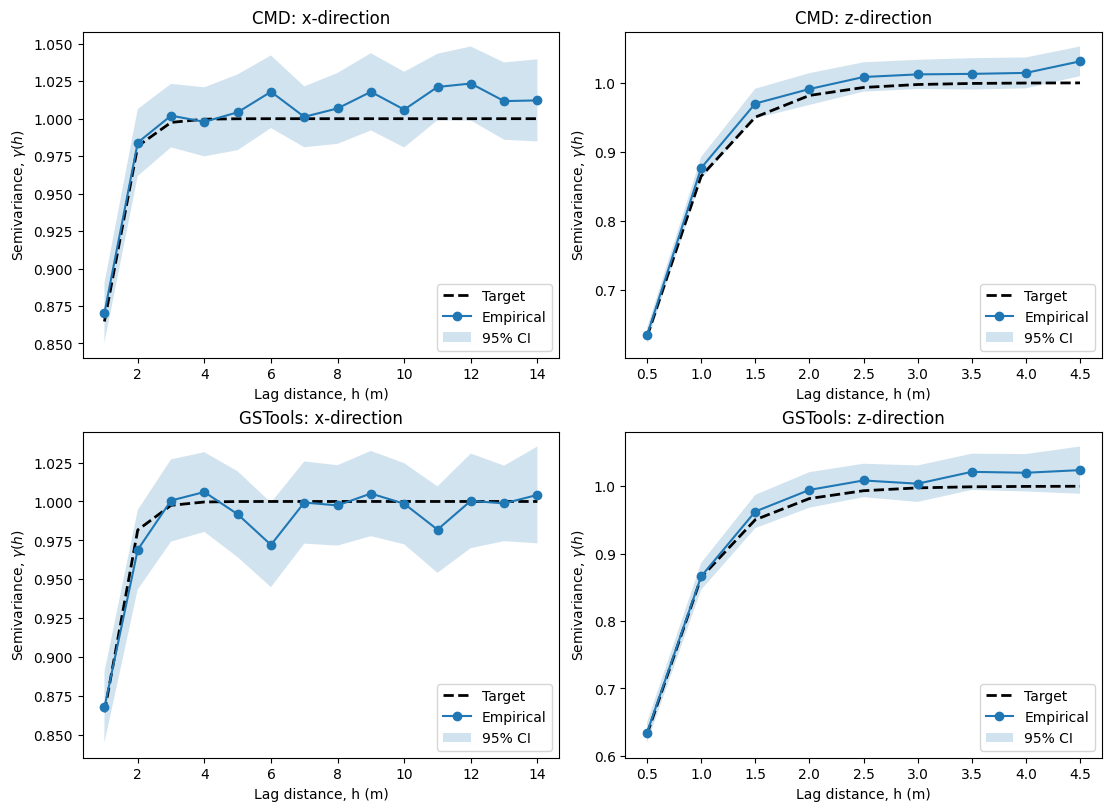

In [7]:
# 8. Plot target versus empirical variograms

fig, axes = plt.subplots(
    2,
    2,
    figsize=(11, 8),
    constrained_layout=True,
)

for row, method in enumerate(("CMD", "GSTools")):

    for col, direction in enumerate(("x", "z")):

        result = variogram_results[
            (method, direction)
        ]

        ax = axes[row, col]

        ax.plot(
            result["lags"],
            result["target"],
            "k--",
            linewidth=2,
            label="Target",
        )

        ax.plot(
            result["lags"],
            result["empirical"],
            "o-",
            label="Empirical",
        )

        ax.fill_between(
            result["lags"],
            result["empirical"] - result["ci95"],
            result["empirical"] + result["ci95"],
            alpha=0.2,
            label="95% CI",
        )

        ax.set_title(
            f"{method}: {direction}-direction"
        )

        ax.set_xlabel(
            "Lag distance, h (m)"
        )

        ax.set_ylabel(
            r"Semivariance, $\gamma(h)$"
        )

        ax.legend()

plt.show()

In [8]:
# Single-grid benchmark

single_run_rows = []

for i, method in enumerate(("CMD", "GSTools")):

    _, elapsed, peak_memory = (
        measure_time_and_peak_memory(
            simulation_task,
            method,
            points,
            field_shape,
            base_seed + i,
            mode_no=mode_no,
        )
    )

    single_run_rows.append(
        {
            "method": method,
            "n_cells": points.shape[0],
            "time_s": elapsed,
            "additional_peak_memory_mib": peak_memory,
        }
    )


single_run_benchmark = pd.DataFrame(
    single_run_rows
)

print("\nSingle-grid benchmark:")
print(single_run_benchmark)


Single-grid benchmark:
    method  n_cells    time_s  additional_peak_memory_mib
0      CMD      600  1.614131                   72.312500
1  GSTools      600  1.641143                   58.210938



Grid-size scalability:
     method   nx   nz  n_cells     time_s  additional_peak_memory_mib  \
0       CMD   10   10      100  11.269204                   58.320312   
1   GSTools   10   10      100  10.634807                   58.113281   
2       CMD   15   15      225  10.467878                   59.765625   
3   GSTools   15   15      225   5.097641                   58.136719   
4       CMD   20   20      400   8.122797                   62.878906   
5   GSTools   20   20      400   5.232886                   58.039062   
6       CMD   25   25      625   2.642676                   72.125000   
7   GSTools   25   25      625   1.959852                   58.093750   
8       CMD   30   30      900   2.088451                   86.472656   
9   GSTools   30   30      900   1.884583                   57.937500   
10      CMD   50   50     2500   3.741441                  299.890625   
11  GSTools   50   50     2500   2.426354                   57.941406   
12      CMD  100  100    10

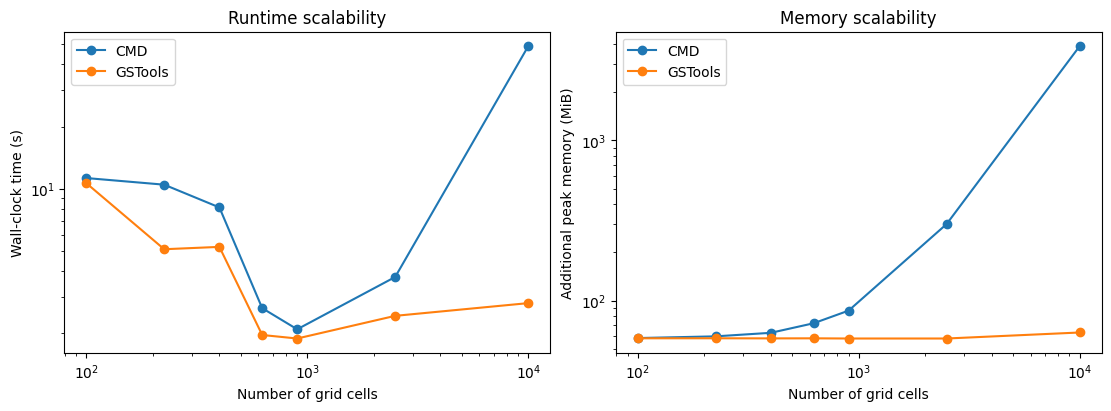

In [9]:
# 11. Grid-size scalability

grid_shapes = [
    (10, 10),
    (15, 15),
    (20, 20),
    (25, 25),
    (30, 30),
    (50, 50),
    (100, 100),
]

scalability_rows = []

for nx, nz in grid_shapes:

    _, _, benchmark_points = make_grid(
        x_span=x_span,
        z_span=z_span,
        nx=nx,
        nz=nz,
    )

    benchmark_shape = (nx, nz)

    for i, method in enumerate(("CMD", "GSTools")):

        try:
            _, elapsed, peak_memory = (
                measure_time_and_peak_memory(
                    simulation_task,
                    method,
                    benchmark_points,
                    benchmark_shape,
                    base_seed + i,
                    mode_no=mode_no,
                )
            )

            status = "completed"

        except (MemoryError, np.linalg.LinAlgError) as error:

            elapsed = np.nan
            peak_memory = np.nan
            status = type(error).__name__

        scalability_rows.append(
            {
                "method": method,
                "nx": nx,
                "nz": nz,
                "n_cells": nx * nz,
                "time_s": elapsed,
                "additional_peak_memory_mib": peak_memory,
                "status": status,
            }
        )


scalability = pd.DataFrame(
    scalability_rows
)

print("\nGrid-size scalability:")
print(scalability)

# 12. Plot scalability

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4),
    constrained_layout=True,
)

for method, group in scalability.groupby("method"):

    completed = group[
        group["status"] == "completed"
    ]

    axes[0].loglog(
        completed["n_cells"],
        completed["time_s"],
        "o-",
        label=method,
    )

    axes[1].loglog(
        completed["n_cells"],
        completed["additional_peak_memory_mib"],
        "o-",
        label=method,
    )


axes[0].set_xlabel("Number of grid cells")
axes[0].set_ylabel("Wall-clock time (s)")
axes[0].set_title("Runtime scalability")
axes[0].legend()

axes[1].set_xlabel("Number of grid cells")
axes[1].set_ylabel("Additional peak memory (MiB)")
axes[1].set_title("Memory scalability")
axes[1].legend()

plt.show()


Ensemble-size scalability:
    method  n_realizations  total_time_s  time_per_realization_s
0      CMD               1      0.011265                0.011265
1      CMD               5      0.064580                0.012916
2      CMD              10      0.114549                0.011455
3  GSTools               1      0.028363                0.028363
4  GSTools               5      0.175960                0.035192
5  GSTools              10      0.859667                0.085967


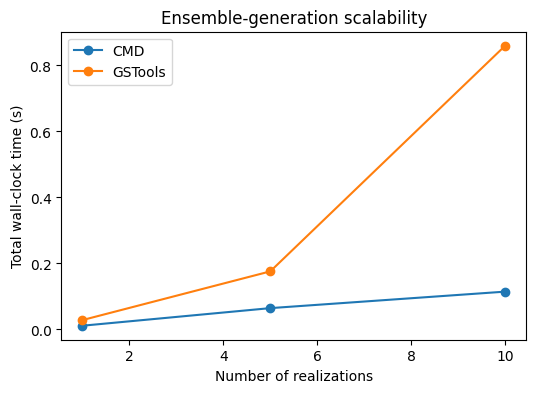

In [10]:
# 13. Ensemble-size scalability

ensemble_sizes = [
    1,
    5,
    10,
]

ensemble_benchmark_rows = []

# Smaller grid to keep repeated CMD calculations practical
x_bench, z_bench, points_bench = make_grid(
    x_span=x_span,
    z_span=z_span,
    nx=20,
    nz=15,
)

shape_bench = (
    len(x_bench),
    len(z_bench),
)

for method in ("CMD", "GSTools"):

    for n_fields in ensemble_sizes:

        simulator = build_simulator(
            method=method,
            seed=base_seed,
            mode_no=mode_no,
        )

        start = perf_counter()

        for _ in range(n_fields):

            simulate_one(
                simulator=simulator,
                points=points_bench,
                shape=shape_bench,
            )

        elapsed = perf_counter() - start

        ensemble_benchmark_rows.append(
            {
                "method": method,
                "n_realizations": n_fields,
                "total_time_s": elapsed,
                "time_per_realization_s": (
                    elapsed / n_fields
                ),
            }
        )


ensemble_benchmark = pd.DataFrame(
    ensemble_benchmark_rows
)

print("\nEnsemble-size scalability:")
print(ensemble_benchmark)


fig, ax = plt.subplots(figsize=(6, 4))

for method, group in ensemble_benchmark.groupby(
    "method"
):

    ax.plot(
        group["n_realizations"],
        group["total_time_s"],
        "o-",
        label=method,
    )

ax.set_xlabel("Number of realizations")
ax.set_ylabel("Total wall-clock time (s)")
ax.set_title("Ensemble-generation scalability")
ax.legend()

plt.show()